<a href="https://colab.research.google.com/github/RAHUL2002-k/Accuknox-AI-ML-Assignment/blob/main/Assignment%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment 1

# Starting a small mock API locally so the rest of the notebook can work with real endpoints.
# Running it in a background thread allows the notebook to continue without blocking.
# The data here is static and only meant to simulate external services.






In [14]:
import threading
import time
import requests
import sqlite3
import csv
import os
import pandas as pd
import matplotlib.pyplot as plt
from flask import Flask, jsonify

PORT = 5000
API_URL = f"http://127.0.0.1:{PORT}"
DB_NAME = "assignment.db"
CSV_NAME = "users.csv"

app = Flask(__name__)

BOOKS = [
    {"title": "Deep Learning", "author": "Ian Goodfellow", "year": 2016},
    {"title": "Pattern Recognition", "author": "Christopher Bishop", "year": 2006},
    {"title": "The Hundred-Page ML Book", "author": "Andriy Burkov", "year": 2019},
    {"title": "Neural Networks and Deep Learning", "author": "Michael Nielsen", "year": 2018},
    {"title": "Machine Learning: A Probabilistic Perspective", "author": "Kevin Murphy", "year": 2012},
    {"title": "Data Science from Scratch", "author": "Joel Grus", "year": 2019},
    {"title": "The Elements of Statistical Learning", "author": "Trevor Hastie", "year": 2009},

]

SCORES = [
    {"student": "Rahul", "score": 88},
    {"student": "pandu", "score": 92},
    {"student": "srujan", "score": 79},
    {"student": "jagadesh", "score": 95},
    {"student": "Varshit", "score": 85}
]

@app.route("/books")
def get_books():
    return jsonify(BOOKS)

@app.route("/scores")
def get_scores():
    return jsonify(SCORES)

def start_server():
    app.run(port=PORT, debug=False, use_reloader=False)

if not any(t.name == "api_thread" for t in threading.enumerate()):
    thread = threading.Thread(target=start_server, name="api_thread", daemon=True)
    thread.start()
    time.sleep(1)


# Fetching book data from the API and saving it into a SQLite database.
# The table is created once and reused if it already exists.
# This step mimics a simple API-to-database ingestion flow.


In [17]:
try:
    response = requests.get(f"{API_URL}/books", timeout=5)
    response.raise_for_status()
    books = response.json()
except requests.RequestException as e:
    print("Failed to fetch books:", e)
    books = []

if books:
    with sqlite3.connect(DB_NAME) as conn:
        cursor = conn.cursor()
        cursor.execute(
            "CREATE TABLE IF NOT EXISTS books (id INTEGER PRIMARY KEY, title TEXT, author TEXT, year INTEGER)"
        )

        records = [(b["title"], b["author"], b["year"]) for b in books]
        cursor.execute("DELETE FROM books")
        cursor.executemany(
            "INSERT INTO books (title, author, year) VALUES (?, ?, ?)", records
        )
        conn.commit()

    with sqlite3.connect(DB_NAME) as conn:
        result = pd.read_sql("SELECT title, author, year FROM books", conn)
        print(result)


INFO:werkzeug:127.0.0.1 - - [11/Jan/2026 11:42:31] "GET /books HTTP/1.1" 200 -


                                           title              author  year
0                                  Deep Learning      Ian Goodfellow  2016
1                            Pattern Recognition  Christopher Bishop  2006
2                       The Hundred-Page ML Book       Andriy Burkov  2019
3              Neural Networks and Deep Learning     Michael Nielsen  2018
4  Machine Learning: A Probabilistic Perspective        Kevin Murphy  2012
5                      Data Science from Scratch           Joel Grus  2019
6           The Elements of Statistical Learning       Trevor Hastie  2009


# Pulling student scores from the API to do a quick check on the results.
# Calculating the average score and plotting the values helps spot any obvious outliers.


INFO:werkzeug:127.0.0.1 - - [11/Jan/2026 11:24:52] "GET /scores HTTP/1.1" 200 -


Fetching scores from http://127.0.0.1:5000/scores...
Class Average: 87.80


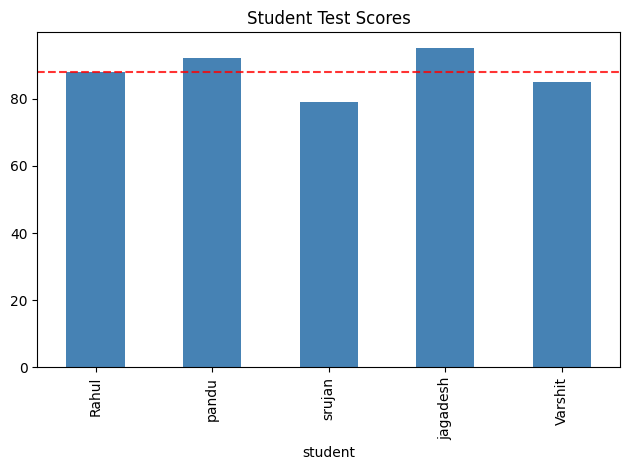

In [10]:
print(f"Fetching scores from {API_URL}/scores...")
resp = requests.get(f"{API_URL}/scores")
scores = resp.json()

if scores:
    df = pd.DataFrame(scores)
    avg = df['score'].mean()

    print(f"Class Average: {avg:.2f}")

    # Quick plot
    ax = df.plot(kind='bar', x='student', y='score', legend=False, color='steelblue')
    ax.set_title("Student Test Scores")
    ax.axhline(avg, color='red', linestyle='--', alpha=0.8, label="Mean")
    plt.tight_layout()
    plt.show()

# Creating a small CSV file and loading its contents into the database.
# This is just to simulate a common CSV import workflow.
# The file is removed afterward to keep things clean.


In [18]:
with open(CSV_NAME, "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["name", "email"])
    writer.writerow(["rahul", "rahul12@example.com"])
    writer.writerow(["varshit", "varshit21@test.com"])

with sqlite3.connect(DB_NAME) as conn:
    cursor = conn.cursor()
    cursor.execute(
        "CREATE TABLE IF NOT EXISTS users (id INTEGER PRIMARY KEY, name TEXT, email TEXT)"
    )

    with open(CSV_NAME, "r") as file:
        reader = csv.DictReader(file)
        data = [(row["name"], row["email"]) for row in reader]
    cursor.execute("DELETE FROM users")

    cursor.executemany(
        "INSERT INTO users (name, email) VALUES (?, ?)", data
    )
    conn.commit()

    users = pd.read_sql("SELECT name, email FROM users", conn)
    print(users)

if os.path.exists(CSV_NAME):
    os.remove(CSV_NAME)


      name                email
0    rahul  rahul12@example.com
1  varshit   varshit21@test.com
